In [4]:
import pandas as pd
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import yaml
import os.path as op
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import matplotlib.patches as mpatches

In [ ]:
def read_all_results(root_dir, select = ('overlaps_global_top_k.tsv')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(select) :

                filepath = os.path.join(dirpath, filename)
                try:
                    overlaps = pd.read_csv(filepath, sep = '\t', index_col=0)
                    overlaps['dataset'] = op.basename(op.dirname(filepath))
                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results


def read_all_results_yaml(root_dir, select = ('clustering_score.json')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(select) :

                filepath = os.path.join(dirpath, filename)
                try:
                    with open(filepath, 'r') as f:
                        yaml_content = yaml.safe_load(f)

                        if not yaml_content or not isinstance(yaml_content, dict):
                            continue # Skip empty or invalid YAML file
                        
                        # The directory one level up is 'CONFIG'
                        net = op.basename(op.dirname(filepath))
                        
                        for key, values in yaml_content.items():
                            record = {
                                "method": key,
                                "clustering_score": values.get("clustering_score"),
                                "training_time": values.get("training_time"),
                                "inference_time": values.get("inference_time"),
                                'dataset': net
                            }
                            all_results.append(record)
                except:
                    pass
                    

    all_results = pd.DataFrame(all_results)

    #all_results['n_clusters'] = all_results['config_dir'].apply(recode_number_of_datasets)


    return all_results

def recode_number_of_datasets(config_item):
    if config_item == 'config_easy':
        return 2
    if config_item == 'config_noise':
        return 2
    if config_item == 'config_three':
        return 3
    if config_item == 'config_three_noise':
        return 3
    if config_item == 'config_five':
        return 5
    if config_item == 'config_ten':
        return 10



In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

def create_heatmap(res, n=None, save_path=None, column_name='Area Over Diagonal', 
                   row_index=None, title='Sorted Method Performance', 
                   show_row_labels=False):
    # 1. Data Preparation
    if row_index is None:
        row_means = res.groupby('method')[column_name].mean().sort_values(ascending=False)
        row_index = row_means.index
    
    if n is not None:
        row_index = row_index[:n]
        
    heatmap_data = res.pivot_table(index='method', 
                                columns='dataset', 
                                values=column_name, 
                                aggfunc='mean').reindex(row_index)

    # --- Double Column Annotation (Size & Net Count) ---
    def get_net_metrics(ds_name):
        nums = re.findall(r'net_([0-9]+)', ds_name)
        net_sum = sum(int(n) for n in nums) if nums else 0
        net_count = len(nums)
        return pd.Series({'Total Size': net_sum, 'Net Count': net_count})

    col_meta = heatmap_data.columns.to_series().apply(get_net_metrics)
    column_colors = pd.DataFrame(index=heatmap_data.columns)
    
    norm_size = plt.Normalize(col_meta['Total Size'].min(), col_meta['Total Size'].max())
    column_colors['Total Size'] = col_meta['Total Size'].apply(lambda x: plt.cm.viridis(norm_size(x)))
    
    norm_count = plt.Normalize(col_meta['Net Count'].min(), col_meta['Net Count'].max())
    column_colors['Net Count'] = col_meta['Net Count'].apply(lambda x: plt.cm.cividis(norm_count(x)))

    # 2. Metadata Preparation (Row Colors & Updated Legend)
    meta_cols = ['xai_method', 'hidden_layer_size', 'n_hidden_layers', 'dropout', 'model', 'background']
    metadata_df = res.drop_duplicates(subset='method').set_index('method').reindex(heatmap_data.index)

    color_grid = pd.DataFrame(index=heatmap_data.index)
    master_palette = list(sns.color_palette("tab20")) + list(sns.color_palette("tab20b"))
    color_idx = 0
    legend_handles = []

    # --- ADD COLUMN METADATA TO LEGEND ---
    legend_handles.append(mpatches.Patch(color='none', label='-- COLUMN METRICS (Top) --'))
    
    # Represent Total Size (Viridis)
    legend_handles.append(mpatches.Patch(color=plt.cm.viridis(0.1), 
                                         label=f"Size: Min ({int(col_meta['Total Size'].min())})"))
    legend_handles.append(mpatches.Patch(color=plt.cm.viridis(0.9), 
                                         label=f"Size: Max ({int(col_meta['Total Size'].max())})"))
    
    # Represent Net Count (Cividis)
    legend_handles.append(mpatches.Patch(color=plt.cm.cividis(0.1), 
                                         label=f"Net Count: {int(col_meta['Net Count'].min())}"))
    legend_handles.append(mpatches.Patch(color=plt.cm.cividis(0.9), 
                                         label=f"Net Count: {int(col_meta['Net Count'].max())}"))
    
    legend_handles.append(mpatches.Patch(color='none', label=' ')) # Spacer

    for col in meta_cols:
        unique_vals = sorted(metadata_df[col].unique())
        col_colors_list = master_palette[color_idx : color_idx + len(unique_vals)]
        color_idx += len(unique_vals)
        lut = dict(zip(unique_vals, col_colors_list))
        color_grid[col] = metadata_df[col].map(lut)
        
        legend_handles.append(mpatches.Patch(color='none', label=f'-- {col.upper()} --'))
        for val, color in lut.items():
            legend_handles.append(mpatches.Patch(color=color, label=str(val)))

    # 3. Create the Clustermap
    fig_height = min(40, max(8, len(row_index) * 0.4))
    
    g = sns.clustermap(
        heatmap_data,
        row_cluster=False,
        col_cluster=False,
        row_colors=color_grid,
        col_colors=column_colors,
        annot=True,
        fmt=".2f",
        cmap='magma',
        figsize=(14, fig_height),
        dendrogram_ratio=0.01,
        colors_ratio=(0.03, 0.015), 
    )

    # 4. Axes Formatting
    g.ax_heatmap.set_xticklabels([]) 
    g.ax_heatmap.set_xlabel("")      
    g.ax_heatmap.yaxis.tick_left()
    g.ax_heatmap.yaxis.set_label_position("left")

    if not show_row_labels:
        g.ax_heatmap.set_yticklabels([]) 
        g.ax_heatmap.yaxis.set_tick_params(pad=5) 
        y_label_text = ""
        ylabel_pad = 0
    else:
        g.ax_heatmap.yaxis.set_tick_params(pad=120) 
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, horizontalalignment='right', fontsize=10)
        y_label_text = "Method Name"
        ylabel_pad = 20

    g.ax_row_colors.xaxis.tick_top()
    plt.setp(g.ax_row_colors.get_xticklabels(), rotation=90, ha='left', fontsize=8)
    plt.setp(g.ax_col_colors.get_yticklabels(), rotation=0, fontsize=9, va='center')

    # 5. POSITION THE LEGEND & COLORBAR
    cat_legend = g.ax_heatmap.legend(handles=legend_handles, 
                                    title="Architecture & Dataset Metadata", 
                                    bbox_to_anchor=(1.05, 1.0), 
                                    loc='upper left', 
                                    borderaxespad=0.,
                                    fontsize=8)

    g.ax_cbar.set_position([0.68, 0.65, 0.12, 0.01]) 
    g.ax_cbar.set_title('Score', fontsize=12, pad=10)

    # 6. Final Polish
    g.ax_heatmap.set_title(title, fontsize=20, pad=80)
    g.ax_heatmap.set_ylabel(y_label_text, fontsize=14, labelpad=ylabel_pad) 

    if save_path:
        g.savefig(save_path, bbox_inches='tight', dpi=300)

    return g, row_index

In [5]:
res = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_sweep/',  select = ('area_over_diagnoal.tsv'))
split_data = res['method'].str.split('_', expand=True)
split_data.columns = ['xai_method', 'hidden_layer_size', 'n_hidden_layers', 'dropout', 'model', 'background']
res = pd.concat([res, split_data], axis=1)
res.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/parameter_sweep.tsv', sep = '\t')



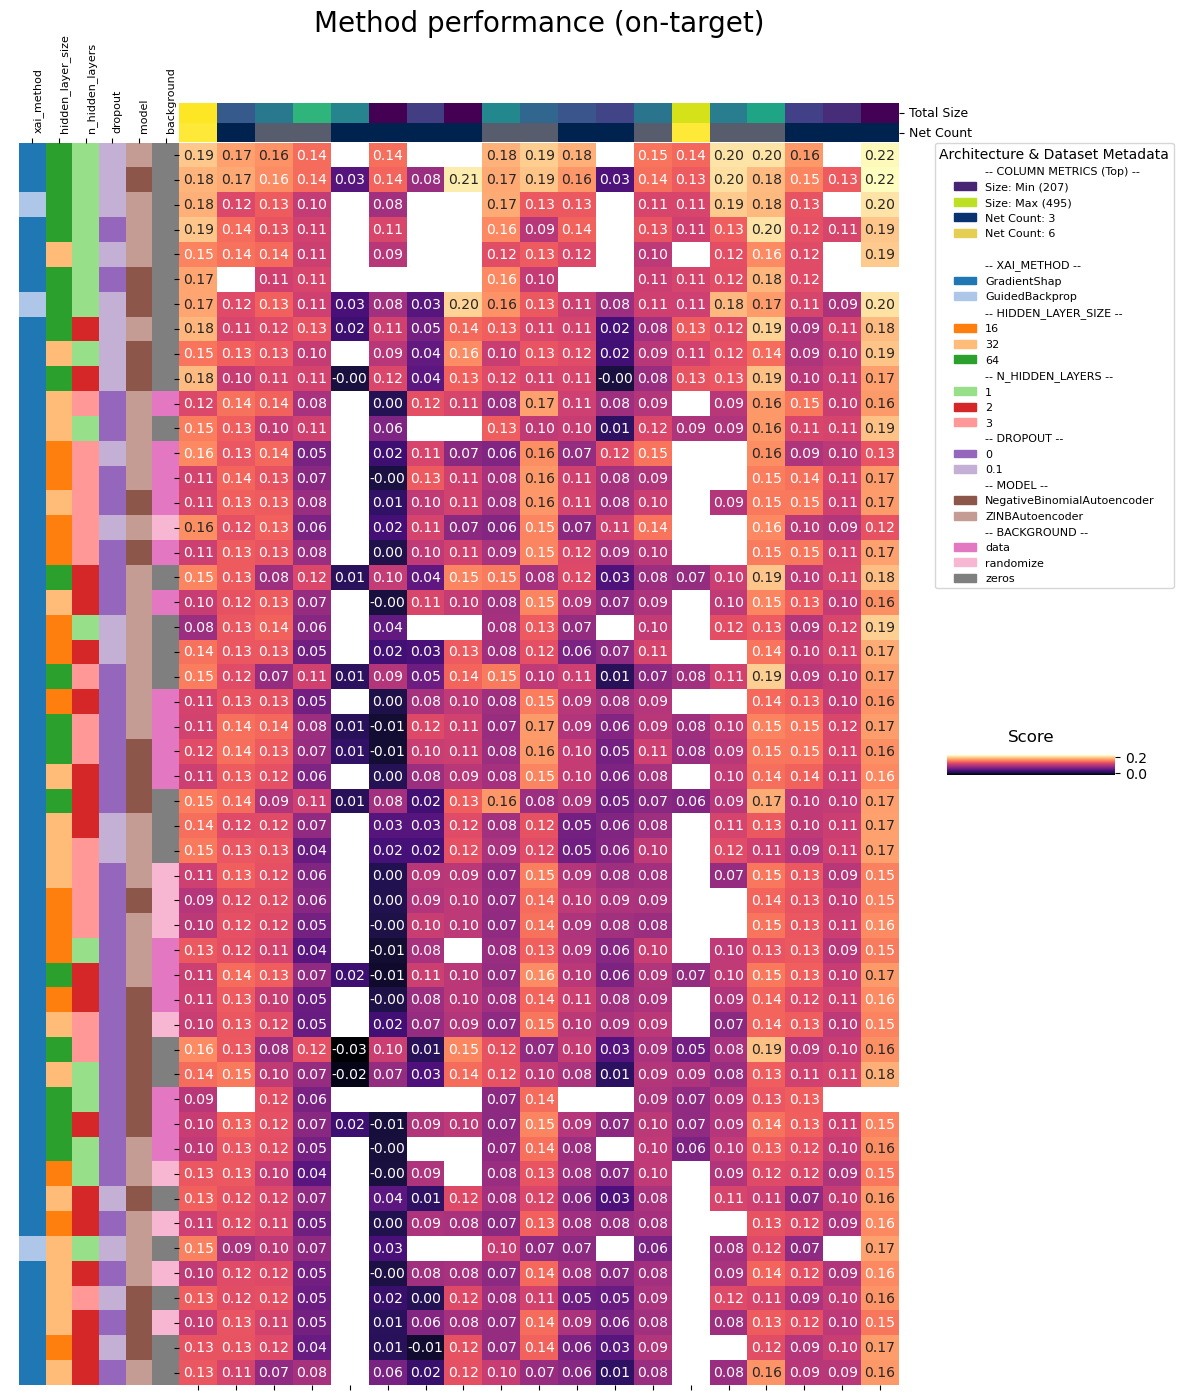

In [29]:
res2 = res[(res.target=='on_target') & (res.direction == 'forward') & (res.net_type == 'strict')].copy()
g, row_idx_forward = create_heatmap(res2, n=50, save_path='/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/on_target_forward.pdf', title="Method performance (on-target)")


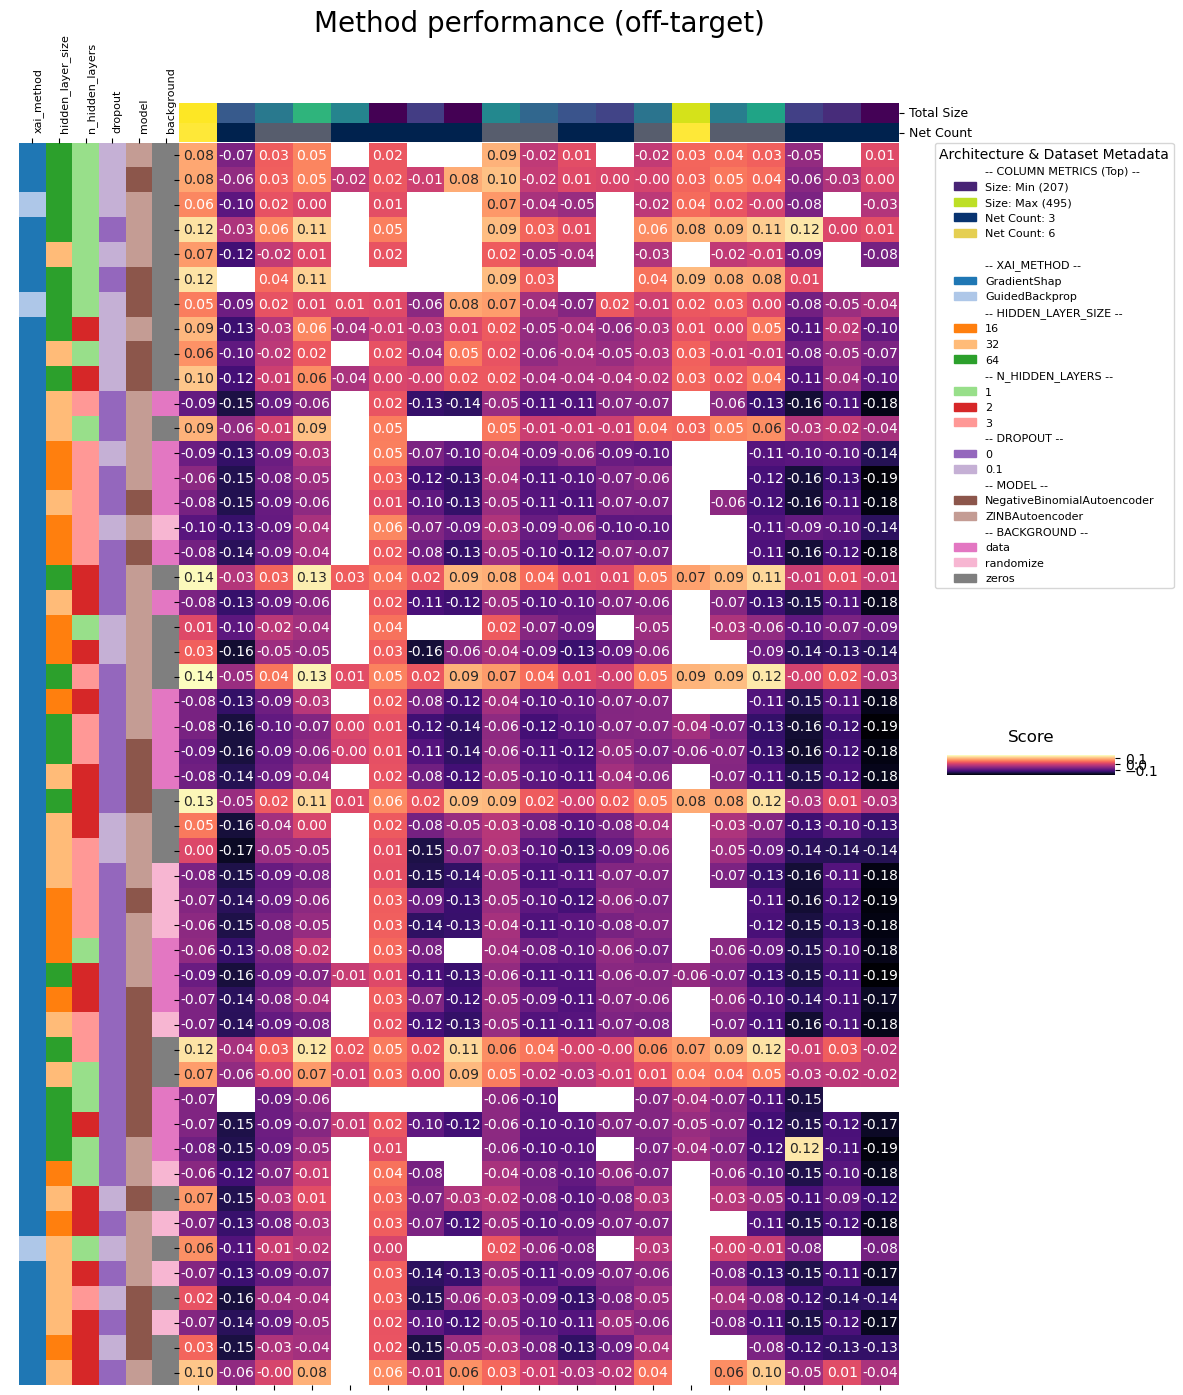

In [30]:
res2 = res[(res.target=='off_target') & (res.direction == 'forward') & (res.net_type == 'strict')].copy()
g = create_heatmap(res2, n=50, row_index=row_idx_forward, save_path='/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/off_target_forward.pdf', title='Method performance (off-target)')


In [ ]:
df_results_leiden = read_all_results_yaml('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_sweep/', select=('clustering_score.json'))
df_results_leiden.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/clustering_scores_runtimes.tsv')

In [12]:
split_data = df_results_leiden['method'].str.split('_', expand=True)
split_data.columns = ['xai_method', 'hidden_layer_size', 'n_hidden_layers', 'dropout', 'model', 'background']
df_results_leiden = pd.concat([df_results_leiden, split_data], axis=1)

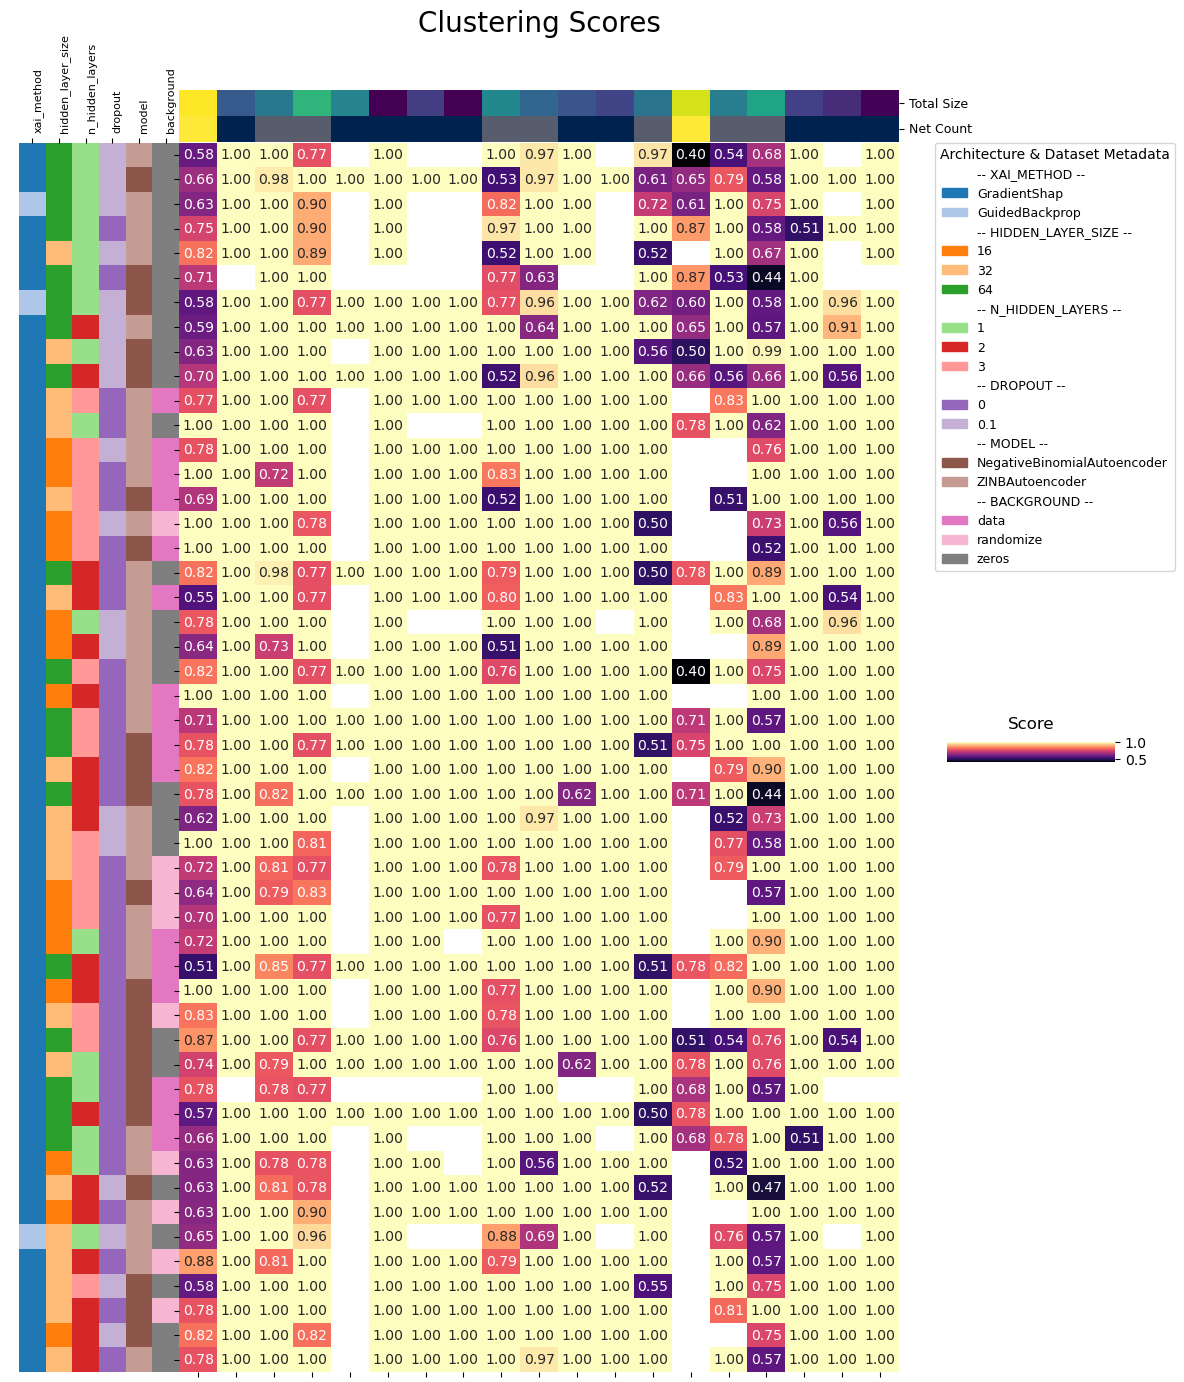

In [13]:
gg, idx2 = create_heatmap(df_results_leiden, n=50, column_name='clustering_score', row_index=row_idx_forward, title='Clustering Scores', save_path='/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/clustering_scores.pdf')

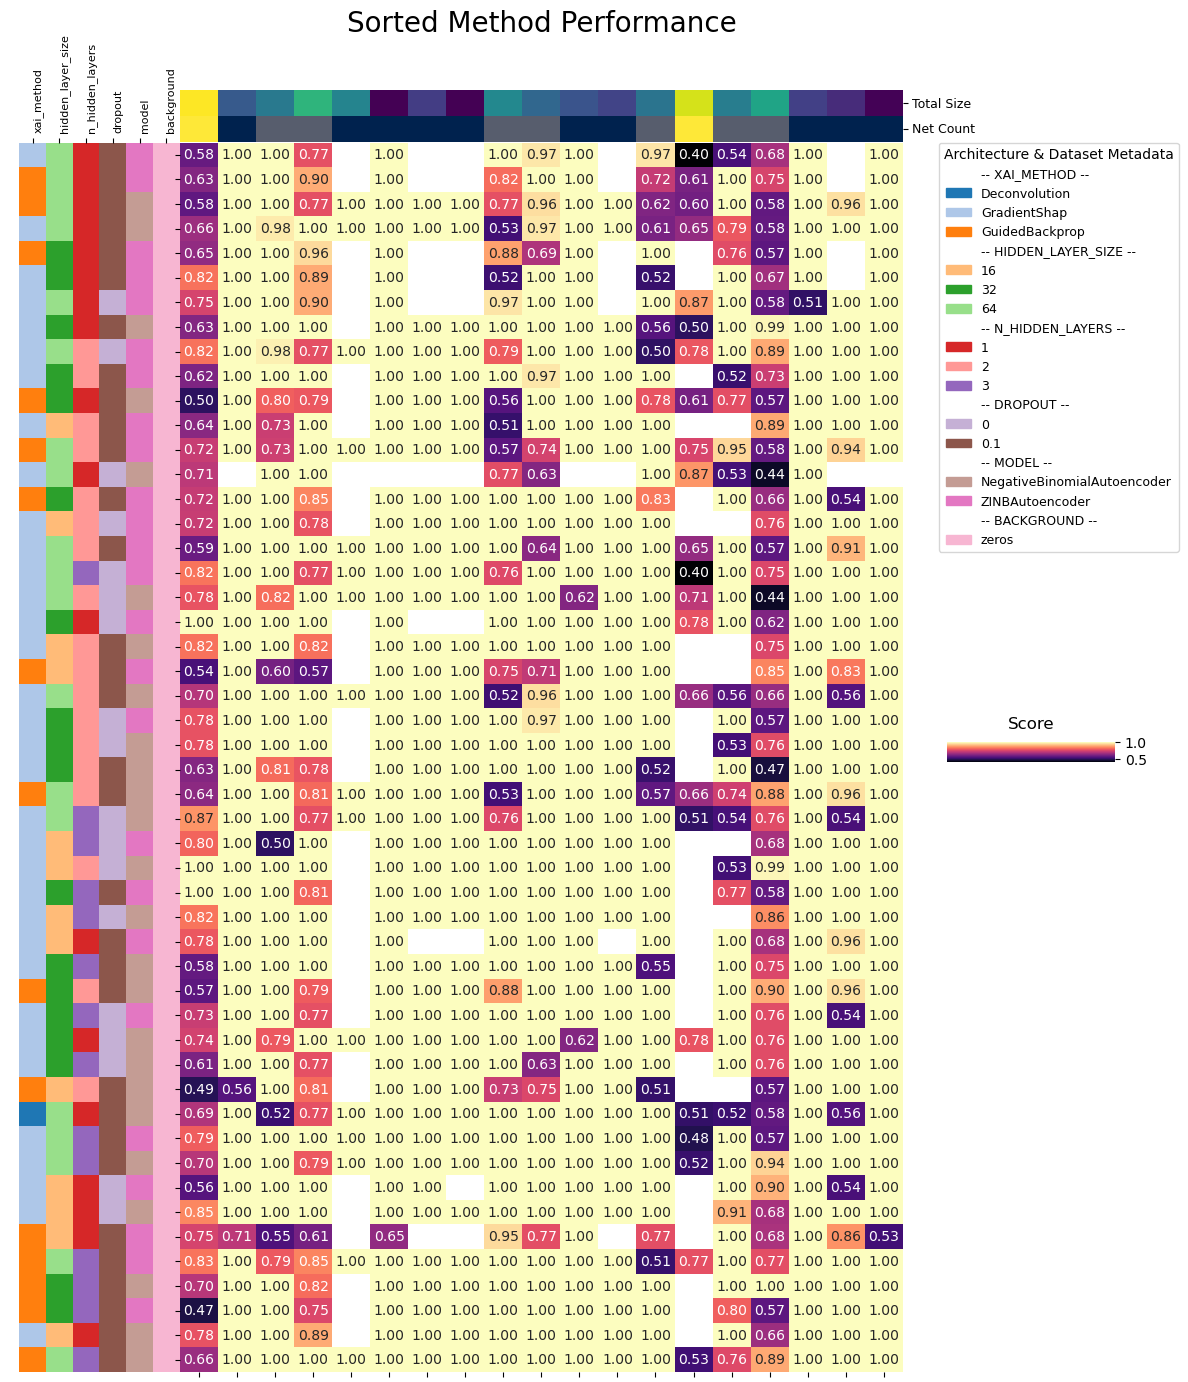

In [14]:
gg, idx2 = create_heatmap(df_results_leiden,n=50, column_name='clustering_score', row_index=row_index)